## Dataset

The Titanic dataset is one of the most well-known datasets used for demonstrating various analytical methods and visualization techniques.

The dataset used in this project is based on the classic Titanic dataset and has been enriched with additional information sourced from Wikipedia.

The version provided here corresponds to the **training subset ("train")**, which is commonly used as a starting point for introductory machine learning projects, exploratory data analysis, feature engineering, and predictive modeling experiments.

Due to its popularity and well-documented structure, the Titanic dataset serves as an excellent benchmark for comparing analytical approaches, visualization techniques, and machine learning workflows.

In this analysis, the focus is exclusively on analytical techniques and methodological approaches. 
The quality or consistency of the underlying data is not evaluated. In particular, whether the Wikipedia-derived information fully aligns with the original dataset is not part of the scope of this work.

In [1]:
# Import of Libraries

import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
# Data Import

df_raw=pd.read_csv('Titanic_full.csv')
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   passenger_id  1309 non-null   int64  
 1   survived      891 non-null    float64
 2   pclass        1309 non-null   int64  
 3   name          1309 non-null   object 
 4   sex           1309 non-null   object 
 5   age           1046 non-null   float64
 6   sibsp         1309 non-null   int64  
 7   parch         1309 non-null   int64  
 8   ticket        1309 non-null   object 
 9   fare          1308 non-null   float64
 10  cabin         295 non-null    object 
 11  embarked      1307 non-null   object 
 12  wiki_id       1304 non-null   float64
 13  name_wiki     1304 non-null   object 
 14  age_wiki      1302 non-null   float64
 15  hometown      1304 non-null   object 
 16  boarded       1304 non-null   object 
 17  destination   1304 non-null   object 
 18  lifeboat      502 non-null  

## Dataset Refinement

The dataset overview reveals that some of the original attributes contain incomplete or missing information.

By incorporating additional data sourced from Wikipedia, a more complete and reliable representation of the passengers can be achieved.

As a result, the dataset is refined as follows:

- The original **`Age`** column is replaced by the corresponding age information provided in the Wikipedia-enriched dataset.
- The **`Cabin`** column is removed due to its high proportion of missing values and limited analytical relevance for the intended use cases.
- The **`Body`** column is removed, as it is sparsely populated and primarily relevant for post-disaster recovery records rather than predictive or exploratory analyses.
- The Wikipedia-derived **`Class`** column is removed, as the original passenger class information in the dataset is more complete and therefore preferred for analysis.

These adjustments reduce dataset complexity while improving overall data quality and consistency.

### Working DataFrame

To preserve the original dataset, a dedicated **working DataFrame** is created from the raw DataFrame.

All transformations, data cleaning steps, feature engineering activities, and exploratory analyses are performed on this working copy. 

This approach ensures that the original dataset remains unchanged and can always serve as a reliable reference point throughout the analysis process.

In [3]:
df = df_raw.drop(columns=['age','cabin', 'body', 'class', 'embarked', 'name_wiki', 'wiki_id']) # reducing the dataset
df = df.rename(columns={'age_wiki': 'age', 'pclass': 'class', 'fare': 'ticketprice'})# Renaming some columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   passenger_id  1309 non-null   int64  
 1   survived      891 non-null    float64
 2   class         1309 non-null   int64  
 3   name          1309 non-null   object 
 4   sex           1309 non-null   object 
 5   sibsp         1309 non-null   int64  
 6   parch         1309 non-null   int64  
 7   ticket        1309 non-null   object 
 8   ticketprice   1308 non-null   float64
 9   age           1302 non-null   float64
 10  hometown      1304 non-null   object 
 11  boarded       1304 non-null   object 
 12  destination   1304 non-null   object 
 13  lifeboat      502 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


The dataset contains records for 1309 passengers in total.

However, survival information (`survived`) is only available for 891 passengers. 

The remaining entries originate from the test subset of the dataset, where the target variable is intentionally not provided.

This structure reflects the original machine learning dataset design from kaggle, where the training set includes labels and the test set is used for prediction without ground truth.

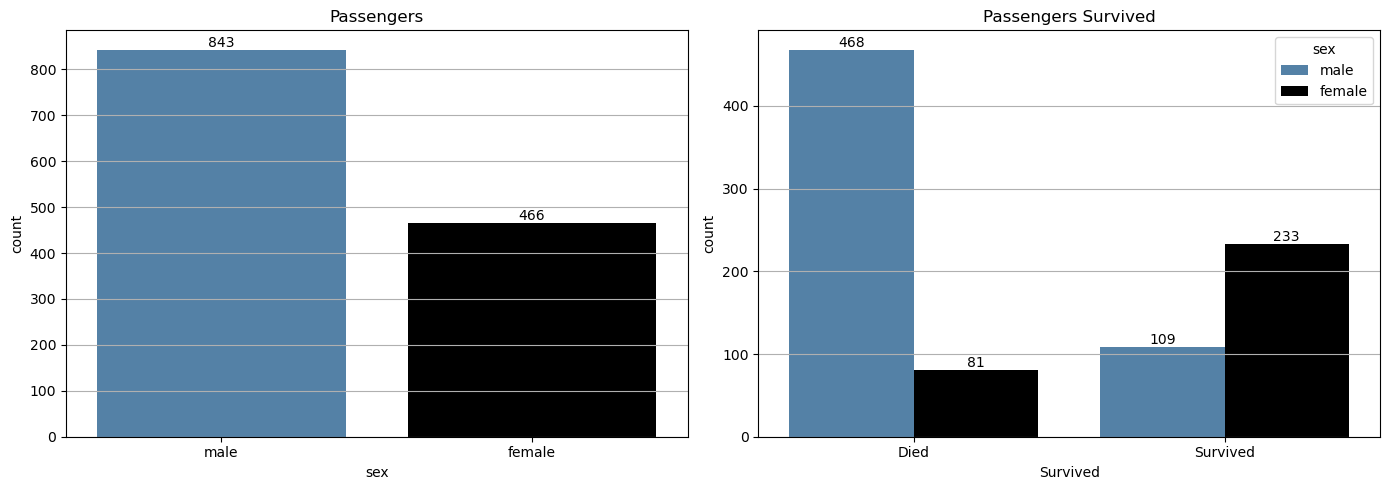


# NaN Survived: 418

Survival rate (%):
sex
female    74.20
male      18.89
Name: survived, dtype: float64

Passenger survival rate: 26.13%


In [4]:
df['survived_label'] = df['survived'].map({0.0: 'Died', 1.0: 'Survived'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Passengers ---
axes[0].set_title('Passengers')

ax1 = sns.countplot(
    data=df,
    x='sex',
    hue='sex',
    palette={'male': 'steelblue', 'female': 'black'},
    ax=axes[0]
)
axes[0].set_xlabel('sex')
axes[0].grid(axis='y')

for container in axes[0].containers:
    axes[0].bar_label(container)

# --- Plot 2: Survived ---
axes[1].set_title('Passengers Survived')

ax2 = sns.countplot(
    data=df,
    x='survived_label',
    hue='sex',
    palette={'male': 'steelblue', 'female': 'black'},
    ax=axes[1]
)
axes[1].set_xlabel('Survived')
axes[1].grid(axis='y')

for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.show()

print('\n# NaN Survived: '+ str(df['survived'].isna().sum()))

rates = df.groupby('sex')['survived'].mean() * 100

print('\nSurvival rate (%):')
print(rates.round(2))
p_s_rate=df['survived'].sum()/len(df)*100
print(f'\nPassenger survival rate: {p_s_rate:.2f}%')

Although the absolute number of male passengers is higher overall, a significantly larger proportion of female passengers survived.

This pattern is clearly reflected in the survival statistics, indicating a strong relationship between gender and survival outcome in the dataset.

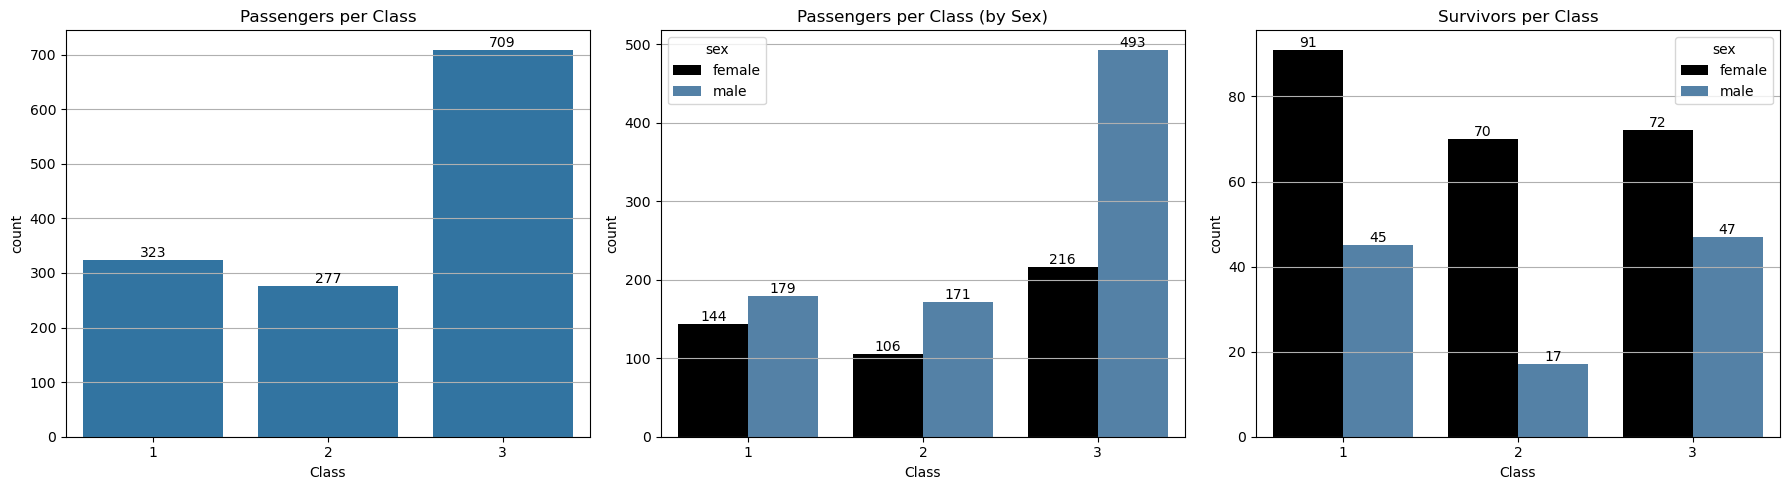

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Class distribution ---
axes[0].set_title('Passengers per Class')

ax1 = sns.countplot(data=df, x='class', ax=axes[0])

axes[0].set_xlabel('Class')
axes[0].grid(axis='y')

for container in axes[0].containers:
    axes[0].bar_label(container)

# --- Plot 2: Class + Sex ---
axes[1].set_title('Passengers per Class (by Sex)')
ax2 = sns.countplot(
    data=df,
    x='class',
    hue='sex',
    palette={'male': 'steelblue', 'female': 'black'},
    ax=axes[1]
)
axes[1].set_xlabel('Class')
axes[1].grid(axis='y')

for container in axes[1].containers:
    axes[1].bar_label(container)

# --- Plot 3: Survivors per Class ---
axes[2].set_title('Survivors per Class')

ax3 = sns.countplot(
    data=df[df['survived'] == 1],
    x='class',
    hue='sex',
    palette={'male': 'steelblue', 'female': 'black'},
    ax=axes[2]
)
axes[2].set_xlabel('Class')
axes[2].grid(axis='y')

for container in axes[2].containers:
    axes[2].bar_label(container)

plt.tight_layout()
plt.show()

It can be observed that the majority of passengers were travelling in third class.

Across all three classes, male passengers clearly outnumber female passengers. This imbalance is especially pronounced in third class, where the proportion of male passengers is significantly higher compared to the other classes.

It can be observed that female passengers in first class had the highest probability of survival.

This indicates a strong interaction between gender and passenger class, where both factors together significantly influenced survival outcomes.

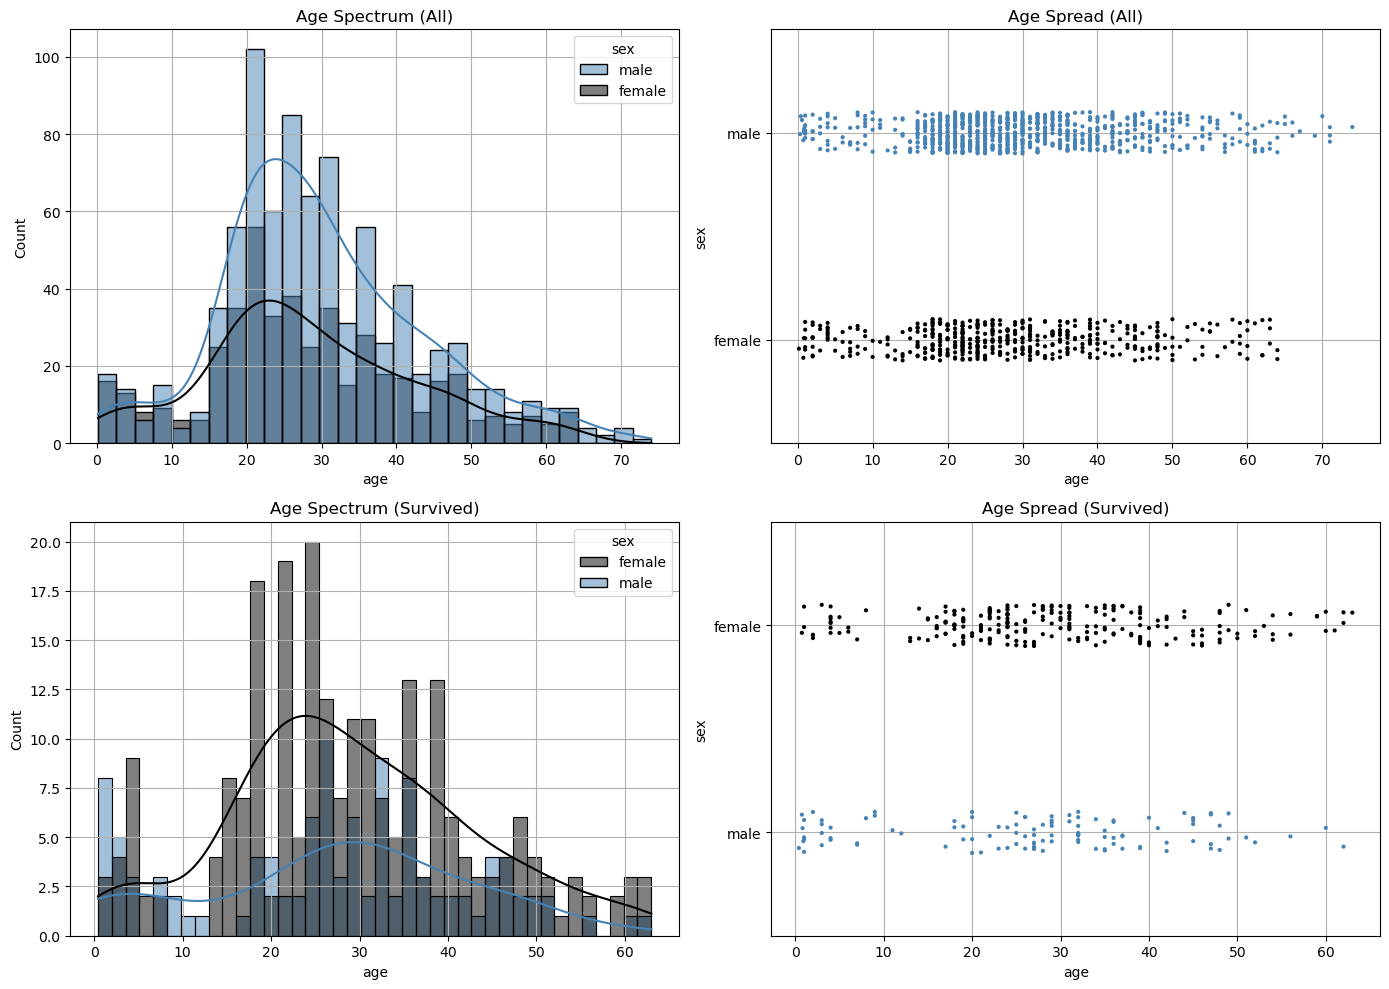


Average Age:
sex
female    28.418467
male      29.966222
Name: age, dtype: float64

Average Age by Survival:
sex     survived
female  0.0         24.296296
        1.0         29.003233
male    0.0         30.840860
        1.0         27.256147
Name: age, dtype: float64


In [6]:
data_survived = df[df['survived'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- (0,0) Histogram all ---
axes[0, 0].set_title('Age Spectrum (All)')

sns.histplot(
    data=df,
    x='age',
    hue='sex',
    bins=30,
    kde=True,
    palette={'male': 'steelblue', 'female': 'black'},
    ax=axes[0, 0]
)
axes[0, 0].grid()

# --- (0,1) Stripplot all ---
axes[0, 1].set_title('Age Spread (All)')

sns.stripplot(
    x='age',
    y='sex',
    hue='sex',
    data=df,
    size=3,
    palette={'male': 'steelblue', 'female': 'black'},
    ax=axes[0, 1]
)
axes[0, 1].grid()

# --- (1,0) Histogram survived ---
axes[1, 0].set_title('Age Spectrum (Survived)')

sns.histplot(
    data=data_survived,
    x='age',
    hue='sex',
    bins=40,
    kde=True,
    palette={'male': 'steelblue', 'female': 'black'},
    ax=axes[1, 0]
)
axes[1, 0].grid()

# --- (1,1) Stripplot survived ---
axes[1, 1].set_title('Age Spread (Survived)')

sns.stripplot(
    x='age',
    y='sex',
    hue='sex',
    data=data_survived,
    size=3,
    palette={'male': 'steelblue', 'female': 'black'},
    ax=axes[1, 1]
)
axes[1, 1].grid()

plt.tight_layout()
plt.show()

print('\nAverage Age:\n'+str(df.groupby('sex')['age'].mean()))
print('\nAverage Age by Survival:\n' + str(df.groupby(['sex', 'survived'])['age'].mean()))

It can be observed that the average age of the passengers is in the late twenties, indicating that the dataset primarily consists of young adults.

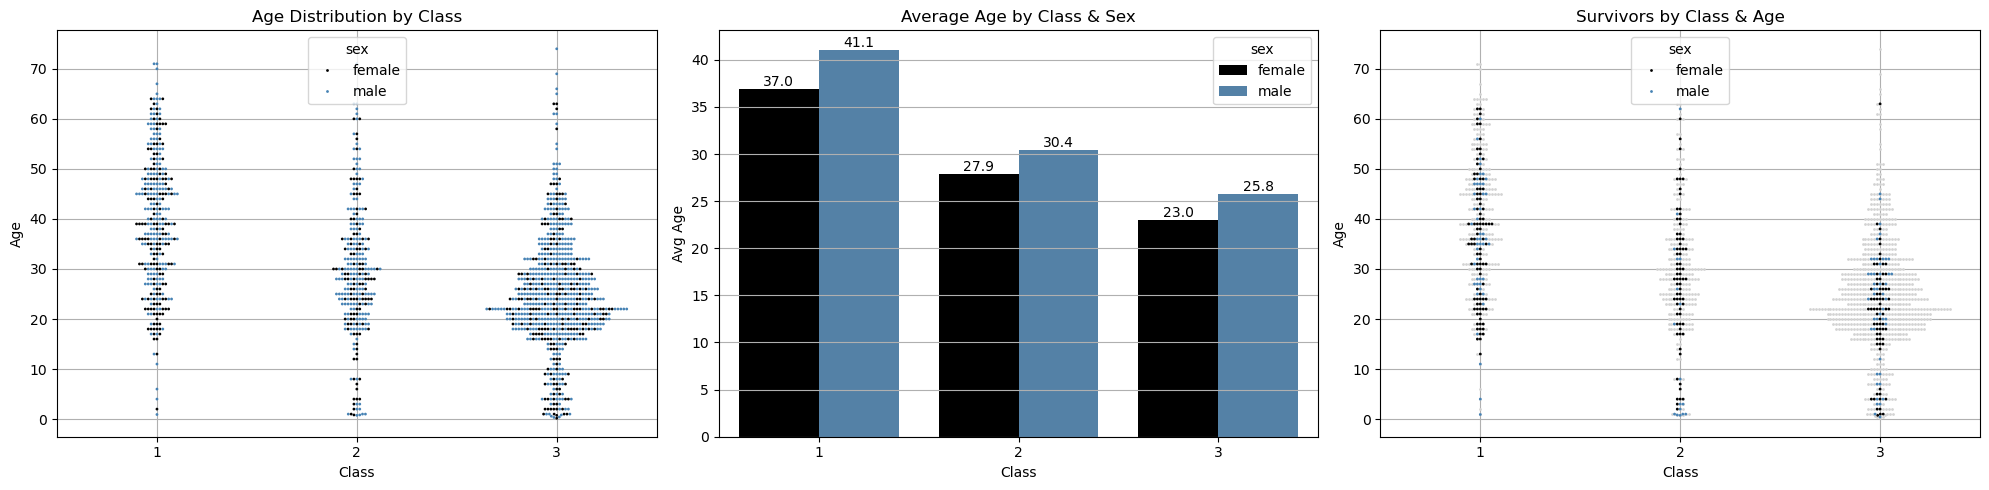

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- 1) Age distribution by class + sex ---
axes[0].set_title('Age Distribution by Class')

sns.swarmplot(
    x='class',
    y='age',
    hue='sex',
    data=df,
    palette={'male': 'steelblue', 'female': 'black'},
    size=2,
    ax=axes[0]
)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Age')
axes[0].grid()

# --- 2) Average age by class + sex ---
axes[1].set_title('Average Age by Class & Sex')

ax = sns.barplot(
    data=df,
    x='class',
    y='age',
    hue='sex',
    estimator='mean',
    errorbar=None,
    palette={'male': 'steelblue', 'female': 'black'},
    ax=axes[1]
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f')


axes[1].set_xlabel('Class')
axes[1].set_ylabel('Avg Age')
axes[1].grid(axis='y')

# --- 3) Survived distribution ---
axes[2].set_title('Survivors by Class & Age')

sns.swarmplot(
    x='class',
    y='age',
    data=df,
    color='lightgray',
    size=2,
    ax=axes[2]
)
sns.swarmplot(
    x='class',
    y='age',
    hue='sex',
    data=df[df['survived'] == 1],
    palette={'male': 'steelblue', 'female': 'black'},
    size=2,
    ax=axes[2]
)
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Age')
axes[2].grid()

plt.tight_layout()
plt.show()

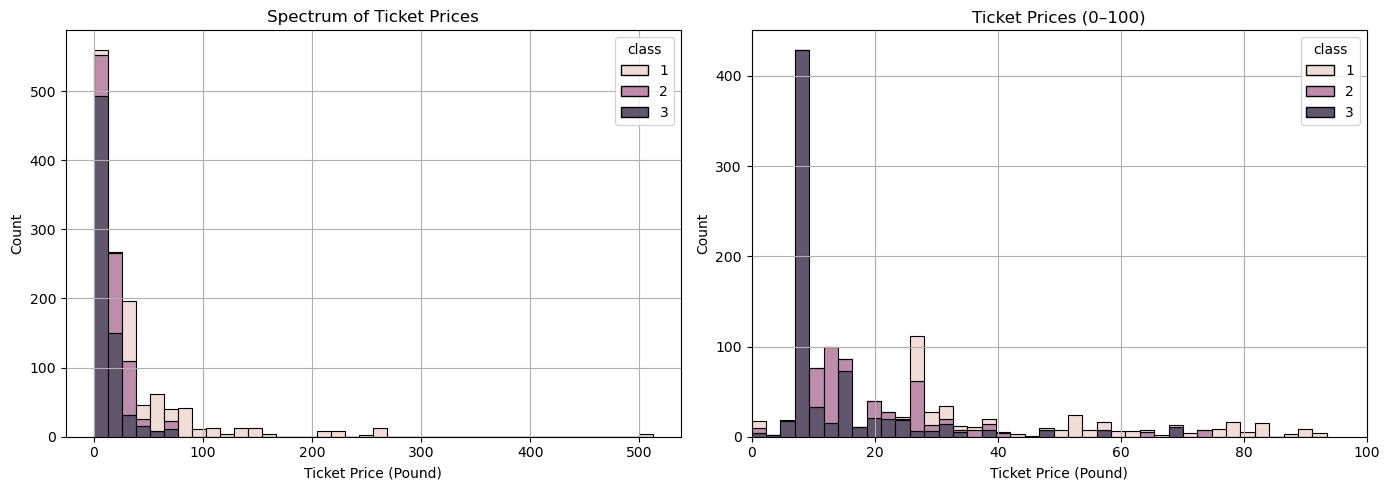

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Full distribution ---
axes[0].set_title('Spectrum of Ticket Prices')

sns.histplot(
    data=df,
    x='ticketprice',
    hue='class',
    bins=40,
    multiple='stack',
    ax=axes[0]
)
axes[0].set_xlabel('Ticket Price (Pound)')
axes[0].grid()

# --- Plot 2: Zoomed (0–100) ---
axes[1].set_title('Ticket Prices (0–100)')

sns.histplot(
    data=df[df['ticketprice'] <= 100],
    x='ticketprice',
    hue='class',
    bins=40,
    multiple='stack',
    ax=axes[1]
)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Ticket Price (Pound)')
axes[1].grid()

plt.tight_layout()
plt.show()

As expected, most ticket prices are concentrated in the range between 0 and 100 pounds, with a clear dominance of fares between 0 and 40 pounds. This indicates that the majority of passengers travelled in lower fare segments, corresponding primarily to second and third class tickets.

# Titanic Fare Inflation & Income Context (1912 → Today)

The Titanic dataset fare values originate from 1912 and are recorded in British Pounds of that time. 
To place these values into a modern economic context, an inflation-adjusted conversion can be applied.

As a rough approximation:

1 GBP (1912) ≈ 130 GBP in today’s purchasing power (based on UK CPI estimates).

This leads to the following interpretation of the observed fare range:

- The range of 0 to 40 GBP corresponds to approximately 0 to around 5,200 GBP today.
- In Euros, this corresponds roughly to 0 to about 6,000 EUR.
- In US Dollars, this corresponds approximately to 0 to around 6,500 USD.

It becomes clear that most fares in the dataset fall within a range that would still represent several thousand units of modern currency. Even the lower fare segment therefore reflects non-trivial economic expenditure in today’s terms.

The fare structure also highlights a strong socioeconomic stratification already present in the dataset, which aligns closely with the passenger class distribution.

---

# Income Context of Third-Class Passengers

Third-class passengers primarily belonged to the working population and often consisted of emigrants and lower-income laborers.

Typical annual wages in Great Britain around 1912 were approximately:

- unskilled workers: £40 – £70 per year  
- factory workers: £60 – £120 per year  
- agricultural workers: £30 – £60 per year  
- skilled workers / craftsmen: £80 – £150 per year  

A third-class Titanic ticket cost approximately £7 to £10.

Relative to annual income, this implies:

- roughly 10% to 25% of a yearly wage  
- or several weeks to months of work

This indicates that traveling in third class was not a routine expense, but a significant financial commitment, often undertaken in the context of emigration and long-term socioeconomic change.

---

# Overall Conclusion

The Titanic fare values correspond to several thousand euros in today’s purchasing power. At the same time, the income context of third-class passengers shows that the journey represented a substantial economic decision, strongly linked to migration and social mobility aspirations rather than leisure travel.

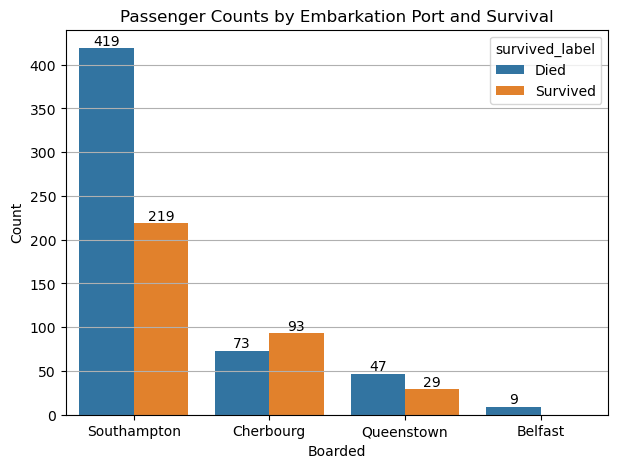

In [9]:
plt.figure(figsize=(7,5))

plt.title('Passenger Counts by Embarkation Port and Survival')

ax = sns.countplot(
    data=df,
    x='boarded',
    hue='survived_label'
)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel('Boarded')
plt.ylabel('Count')

plt.grid(axis='y')

plt.show()

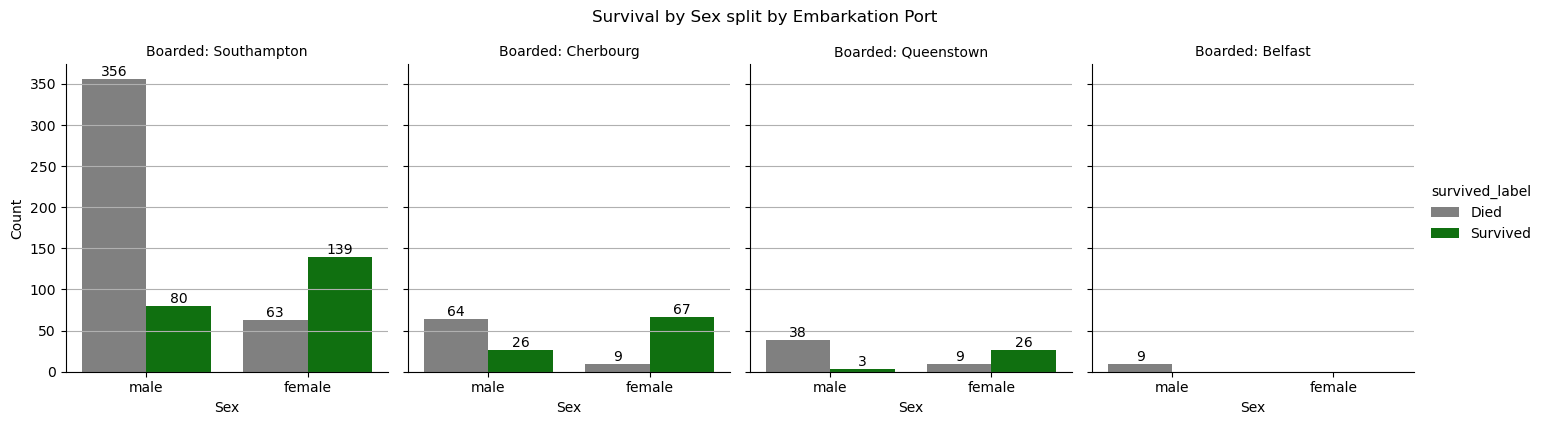

In [10]:
g = sns.catplot(
    data=df,
    kind='count',
    x='sex',
    hue='survived_label',
    col='boarded',
    palette={'Died': 'gray', 'Survived': 'green'},
    height=4,
    aspect=0.9
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)
    ax.grid(axis='y')

g.set_axis_labels('Sex', 'Count')
g.set_titles('Boarded: {col_name}')
g.fig.suptitle('Survival by Sex split by Embarkation Port', y=1.05)

plt.show()

In [11]:
df['title'] = df['name'].str.extract(r' ([A-Za-z]+)\.') # Extracting of Titles

# Titanic Titles – Meaning

## Standard titles
- Mr: adult man, usually lower/middle class passenger
- Mrs: married woman
- Miss: unmarried woman, often younger
- Master: male child / adolescent

## Nobility / high status
- Sir: British honorific for men (knighthood)
- Lady: female noble title
- Countess: very high-ranking noblewoman
- Don: Spanish honorific for men (elite status)
- Dona: female form of Don

## Professional / educated status
- Dr: doctor (physician or academic)
- Rev: reverend (religious authority)

## Military ranks
- Col: colonel
- Major: military officer rank
- Capt: captain

## Language variants
- Mme: French equivalent of Mrs
- Mlle: French equivalent of Miss
- Ms: modern neutral title (Miss/Mrs)

## Rare titles
- Jonkheer: Dutch noble title

## EDA grouping (practical use)
- Elite: Sir, Lady, Countess, Don, Dona, Jonkheer
- Professional: Dr, Rev
- Military: Col, Major, Capt
- Standard: Mr, Mrs, Miss, Master

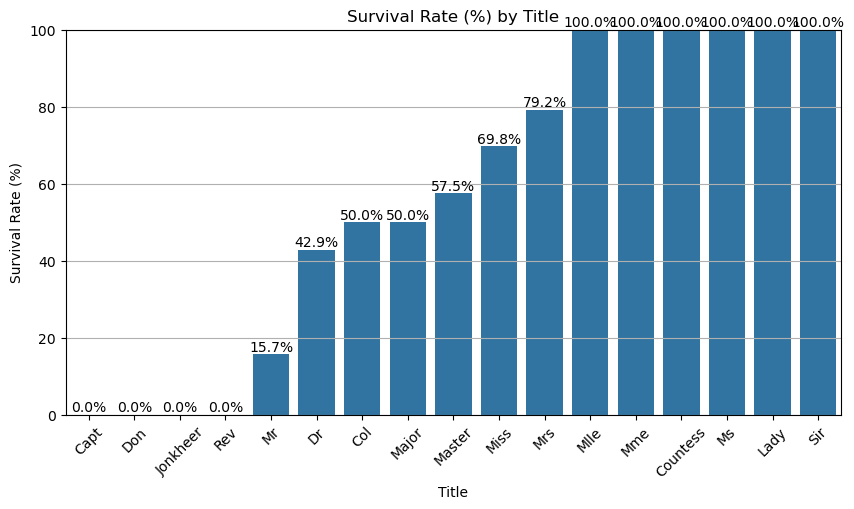

In [12]:

df_clean = df.dropna(subset=['title', 'survived']).copy()

# Mittelwert = Überlebensrate
agg = df_clean.groupby('title')['survived'].mean().reset_index()

# in Prozent umwandeln
agg['survived_pct'] = agg['survived'] * 100

# sortieren
agg = agg.sort_values('survived_pct')

# Plot
plt.figure(figsize=(10,5))
plt.title('Survival Rate (%) by Title')

ax = sns.barplot(
    data=agg,
    x='title',
    y='survived_pct'
)

plt.xticks(rotation=45)

plt.ylabel('Survival Rate (%)')
plt.xlabel('Title')
plt.grid(axis='y')

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylim(0, 100)

plt.show()

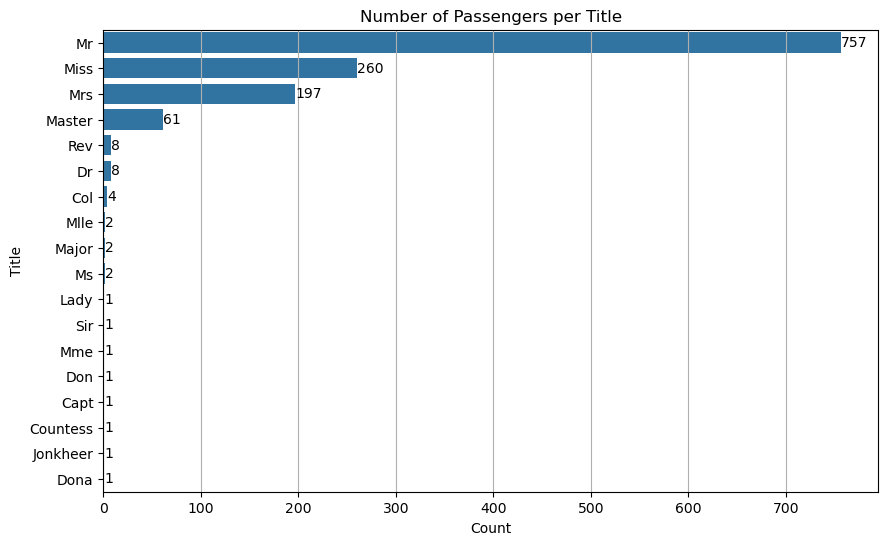

In [13]:
order = df['title'].value_counts().index

plt.figure(figsize=(10,6))
plt.title('Number of Passengers per Title')

ax = sns.countplot(
    data=df,
    y='title',
    order=order
)

ax.bar_label(ax.containers[0])

plt.xlabel('Count')
plt.ylabel('Title')
plt.grid(axis='x')

plt.show()

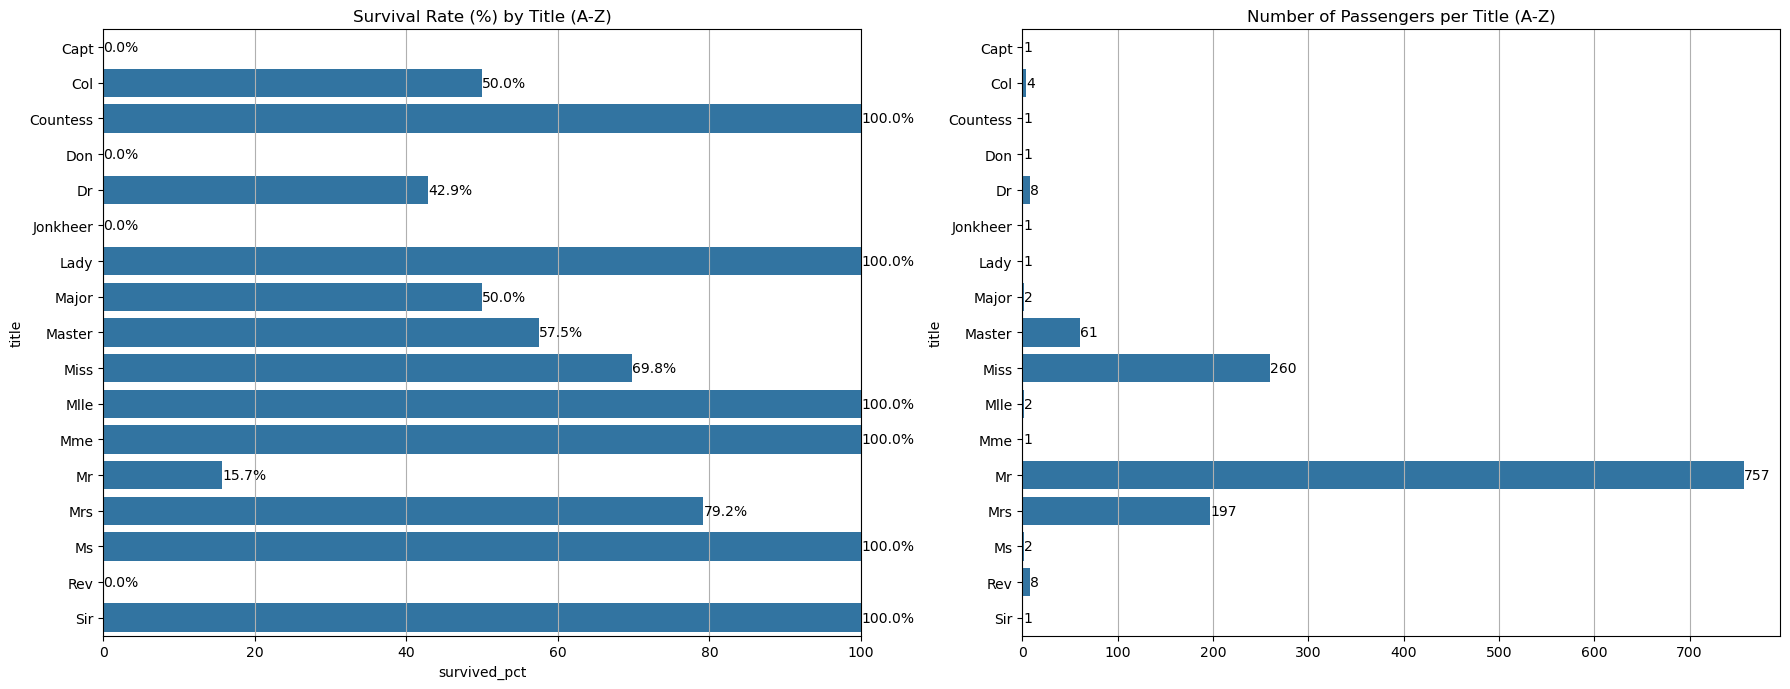

In [14]:
df_clean = df.dropna(subset=['title', 'survived']).copy()

agg = df_clean.groupby('title')['survived'].mean().reset_index()
agg['survived_pct'] = agg['survived'] * 100


order = sorted(agg['title'].unique())

agg = agg.set_index('title').loc[order].reset_index()

count_data = df['title'].value_counts().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Survival
sns.barplot(
    data=agg,
    y='title',
    x='survived_pct',
    order=order,
    ax=axes[0]
)

axes[0].set_title('Survival Rate (%) by Title (A-Z)')
axes[0].set_xlim(0, 100)
axes[0].grid(axis='x')
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%')

# Count
sns.barplot(
    x=count_data.values,
    y=count_data.index,
    ax=axes[1]
)

axes[1].set_title('Number of Passengers per Title (A-Z)')
axes[1].grid(axis='x')
axes[1].bar_label(axes[1].containers[0])

plt.tight_layout()
plt.show()

## Important Note

The title **“Dona” is not included in the analysis**.

This is because it does not appear in the subset of the data used for survival-based calculations (i.e., rows with available survival labels). As a result, it cannot be evaluated in terms of survival rate and is excluded from the aggregated plots.

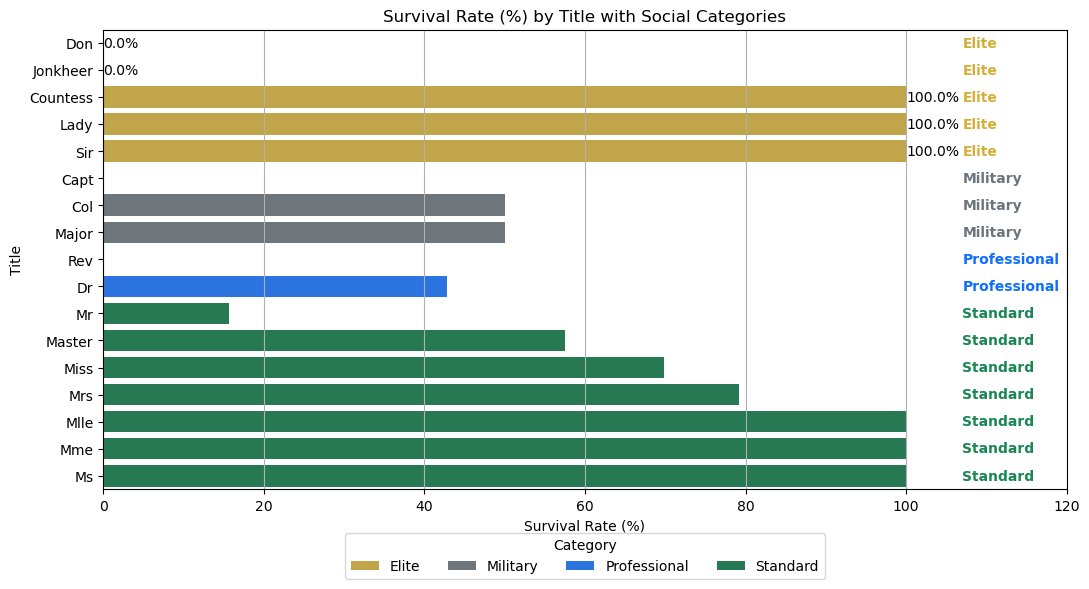

In [15]:
# --- clean data ---
df_clean = df.dropna(subset=['title', 'survived']).copy()

# --- survival rate ---
agg = df_clean.groupby('title')['survived'].mean().reset_index()
agg['survived_pct'] = agg['survived'] * 100

# --- category mapping ---
category_map = {
    'Countess': 'Elite', 'Lady': 'Elite', 'Dona': 'Elite',
    'Don': 'Elite', 'Sir': 'Elite', 'Jonkheer': 'Elite',

    'Capt': 'Military', 'Col': 'Military', 'Major': 'Military',

    'Dr': 'Professional', 'Rev': 'Professional',

    'Master': 'Standard', 'Miss': 'Standard',
    'Mrs': 'Standard', 'Mr': 'Standard',
    'Ms': 'Standard', 'Mme': 'Standard', 'Mlle': 'Standard'
}

agg['category'] = agg['title'].map(category_map)

# --- order ---
order = agg.sort_values(['category', 'survived_pct'])['title']
agg = agg.set_index('title').loc[order].reset_index()

# --- palette ---
palette = {
    'Elite': '#d4af37',
    'Military': '#6c757d',
    'Professional': '#0d6efd',
    'Standard': '#198754'
}

# --- plot ---
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=agg,
    y='title',
    x='survived_pct',
    hue='category',
    dodge=False,
    palette=palette
)

# --- values ---
ax.bar_label(ax.containers[0], fmt='%.1f%%')

# --- category labels (right side, no overlap) ---
for i, row in agg.iterrows():
    ax.text(
        107,          # weiter rechts raus
        i,
        row['category'],
        va='center',
        fontsize=10,
        color=palette[row['category']],
        fontweight='bold'
    )

# --- styling ---
plt.title('Survival Rate (%) by Title with Social Categories')
plt.xlabel('Survival Rate (%)')
plt.ylabel('Title')

plt.xlim(0, 120)
plt.grid(axis='x')

# --- legend below plot ---
plt.legend(
    title='Category',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=4
)

plt.tight_layout()
plt.show()

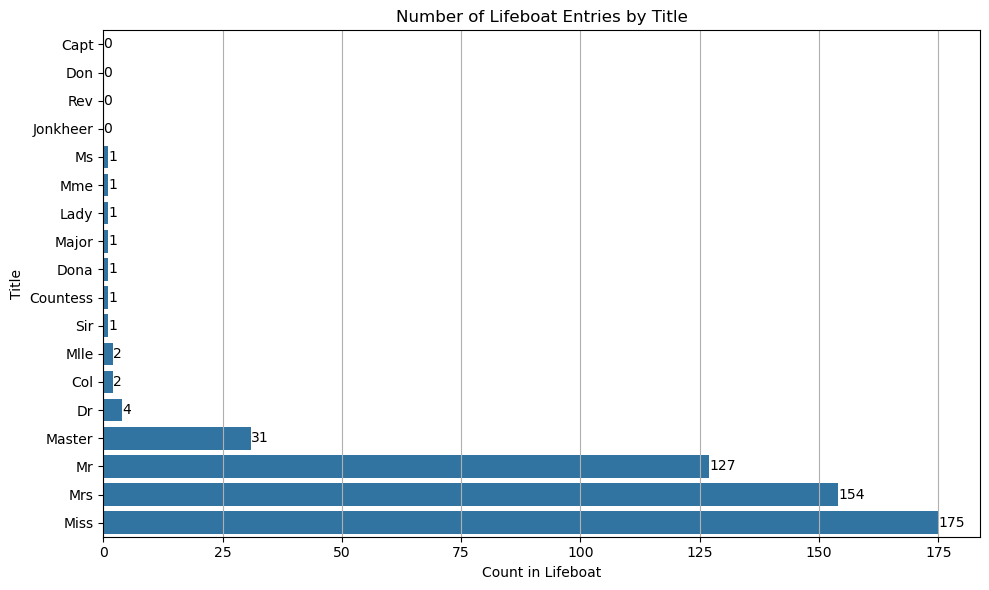

In [16]:

df_clean = df.dropna(subset=['title']).copy()
df_clean['has_boat'] = df_clean['lifeboat'].notna()


agg = df_clean.groupby('title')['has_boat'].sum().reset_index()
agg = agg.sort_values('has_boat')

# --- Plot ---
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=agg,
    y='title',
    x='has_boat'
)

ax.bar_label(ax.containers[0])

plt.title('Number of Lifeboat Entries by Title')
plt.xlabel('Count in Lifeboat')
plt.ylabel('Title')
plt.grid(axis='x')

plt.tight_layout()
plt.show()

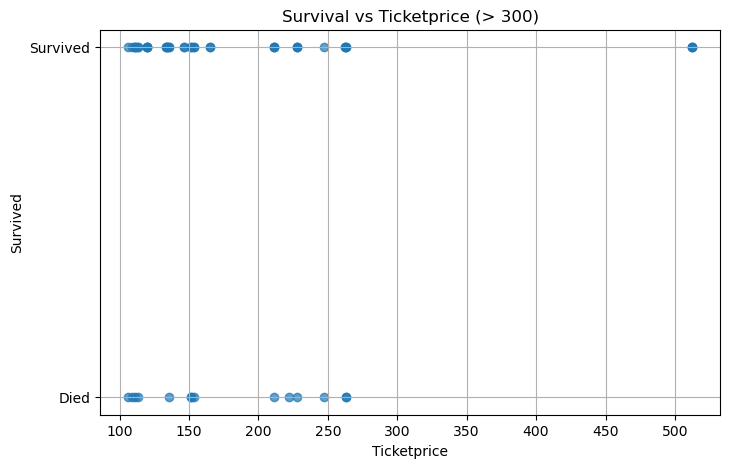

In [17]:
# Filter
df_filtered = df[(df['ticketprice'] > 100) & (df['survived'].notna())]

# Plot
plt.figure(figsize=(8,5))

plt.scatter(
    df_filtered['ticketprice'],
    df_filtered['survived'],
    alpha=0.7
)

plt.title('Survival vs Ticketprice (> 300)')
plt.xlabel('Ticketprice')
plt.ylabel('Survived')
plt.yticks([0, 1], ['Died', 'Survived'])
plt.grid(True)

plt.show()

In [18]:
df[df['ticketprice'] > 500][['ticketprice','name', 'sex', 'class', 'survived']]

,ticketprice,name,sex,class,survived
258,512.3292,"Ward, Miss. Anna",female,1,1.0
679,512.3292,"Cardeza, Mr. Thomas Drake Martinez",male,1,1.0
737,512.3292,"Lesurer, Mr. Gustave J",male,1,1.0
1234,512.3292,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,1,NaN
